 Árboles cargados: 234824
 Árboles con coordenadas: 234824


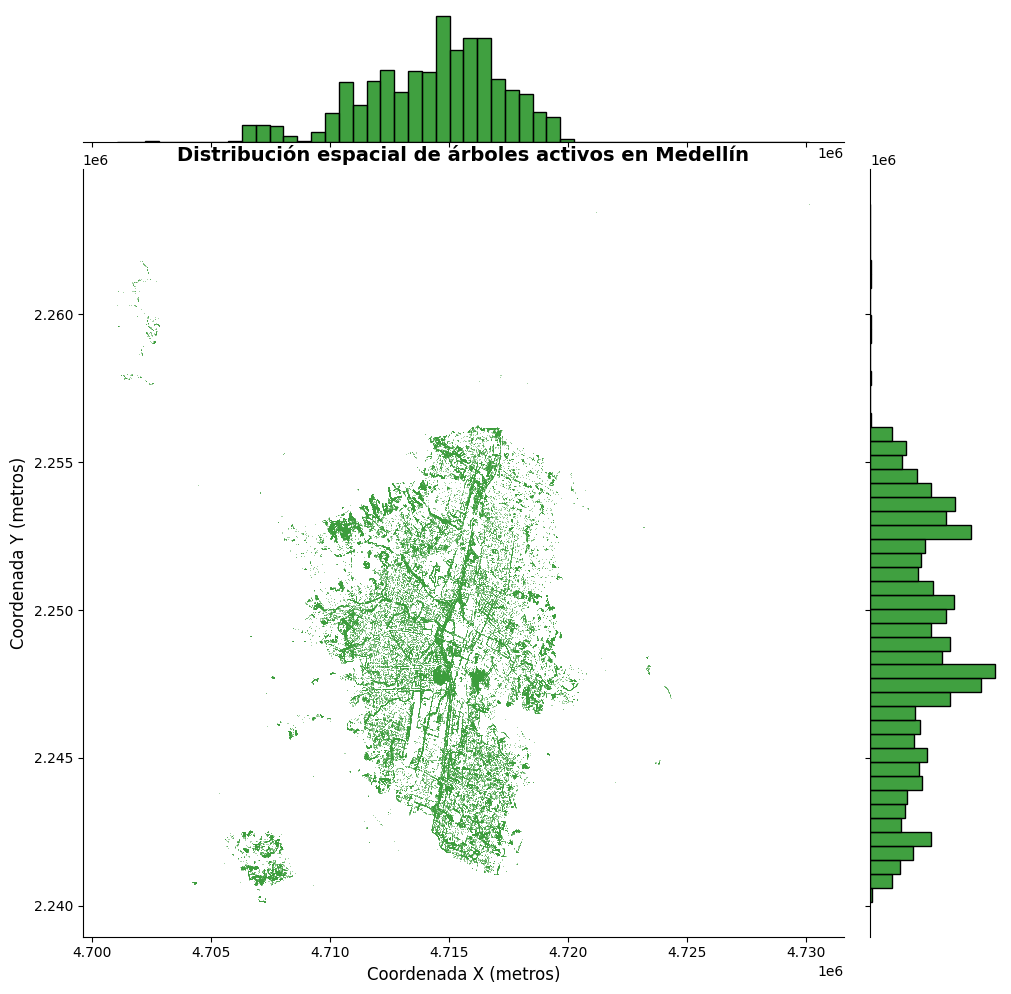

 Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados/Dispersion_Arboles_Medellin.png


In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el archivo con todos los árboles activos en Medellín
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f" Árboles cargados: {len(arboles)}")

# Si los puntos son MultiPoint o Point, extraemos las coordenadas X e Y
# Asegurarnos de que cada registro sea un punto o extraer el centroide si es multipunto
def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        # Tomar el primer punto del MultiPoint (o puedes usar el centroide)
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

# Aplicar la función a la geometría
arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)

# Eliminar filas sin coordenadas (si las hay)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f" Árboles con coordenadas: {len(arboles_clean)}")

# Crear el jointplot
joint_plot = sns.jointplot(
    data=arboles_clean, 
    x='x', 
    y='y', 
    s=0.5,          # Tamaño de los puntos
    color='green',   # Color de los puntos
    alpha=0.5,       # Transparencia para ver la densidad
    height=10,       # Tamaño del gráfico
    marginal_kws=dict(bins=50, fill=True)  # Histogramas en los bordes
)

# Añadir títulos y etiquetas
joint_plot.ax_joint.set_title('Distribución espacial de árboles activos en Medellín', fontsize=14, fontweight='bold')
joint_plot.ax_joint.set_xlabel('Coordenada X (metros)', fontsize=12)
joint_plot.ax_joint.set_ylabel('Coordenada Y (metros)', fontsize=12)

# Guardar el gráfico
ruta_grafico = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados/Dispersion_Arboles_Medellin.png"
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f" Gráfico guardado en: {ruta_grafico}")

 Zonas cargadas: 332
 Árboles cargados: 234824
 Árboles con coordenadas: 234824


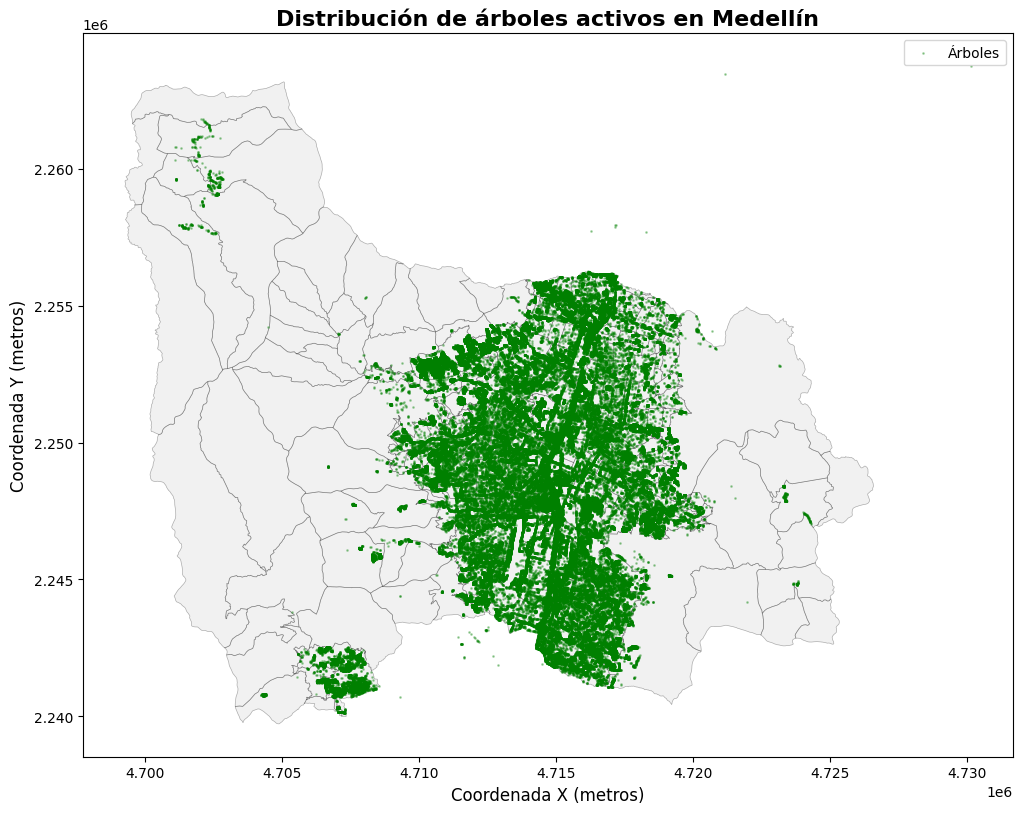

 Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Mapa_Distribucion_Arboles_Medellin.png


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Cargar el polígono de Medellín (usamos las zonas urbanas que ya tienes)
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar los árboles
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f" Zonas cargadas: {len(zonas)}")
print(f" Árboles cargados: {len(arboles)}")

#coordenadas de los árboles
def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        # Tomar el primer punto del MultiPoint
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

# Aplicar la función
arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f" Árboles con coordenadas: {len(arboles_clean)}")

# Mapa

# Configurar la figura
fig, ax = plt.subplots(1, figsize=(12, 10))

# 1. Dibujar los polígonos de Medellín (fondo)
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.5, alpha=0.3)

# 2. Dibujar los árboles como puntos (con transparencia para ver la densidad)
ax.scatter(
    arboles_clean['x'], 
    arboles_clean['y'],
    s=1,                
    c='green',          
    alpha=0.3,        
    label='Árboles'
)

# 3. Configurar el gráfico
ax.set_title('Distribución de árboles activos en Medellín', fontsize=16, fontweight='bold')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

#leyenda
ax.legend(loc='upper right')

# Guardar el gráfico
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
import os
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

ruta_grafico = os.path.join(ruta_resultados, "Mapa_Distribucion_Arboles_Medellin.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f" Gráfico guardado en: {ruta_grafico}")

In [4]:
!pip install contextily

 Zonas cargadas: 332
 Árboles cargados: 234824
 Árboles con coordenadas: 234824


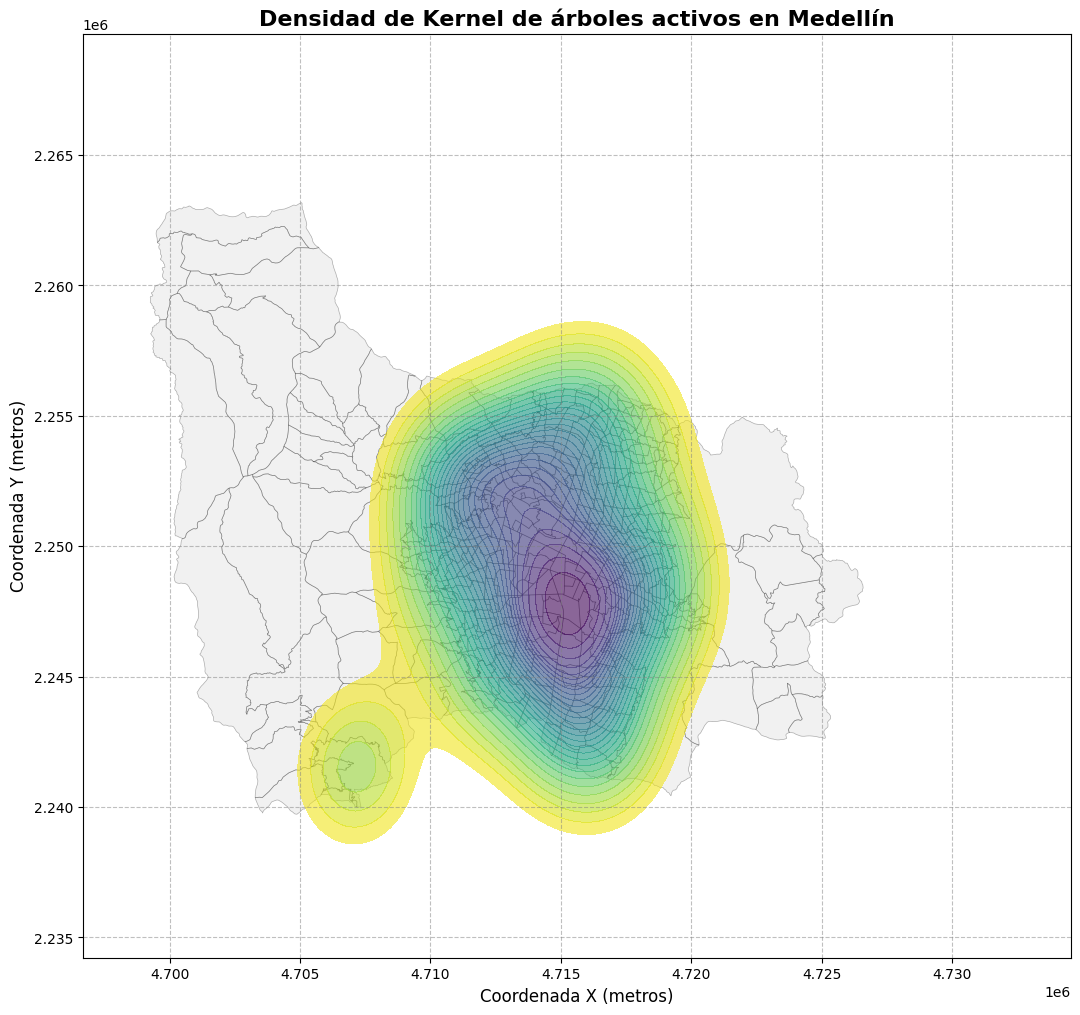

 Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\KDE_Arboles_Medellin_Shapes.png


In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cargar zonas (barrios y veredas)
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar los árboles
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f" Zonas cargadas: {len(zonas)}")
print(f" Árboles cargados: {len(arboles)}")

# Extraer coordenadas

def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f" Árboles con coordenadas: {len(arboles_clean)}")

# Mapa densidad de kernel

# Crear figura y eje
fig, ax = plt.subplots(1, figsize=(14, 12))

zonas.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.5, alpha=0.3)

sns.kdeplot(
    x=arboles_clean['x'], 
    y=arboles_clean['y'],
    ax=ax,
    levels=30,           # Número de curvas de nivel
    fill=True,           # Rellenar las áreas
    alpha=0.6,           # Transparencia
    cmap='viridis_r',    # Mapa de colores (invertido)
    bw_method=0.5,       # Ancho de banda (ajustable)
    thresh=0.05          # Ignorar áreas con densidad muy baja
)

ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

ax.set_title('Densidad de Kernel de árboles activos en Medellín', 
             fontsize=16, fontweight='bold')

# Guardar el gráfico
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

ruta_grafico = os.path.join(ruta_resultados, "KDE_Arboles_Medellin_Shapes.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f" Gráfico guardado en: {ruta_grafico}")

 Zonas cargadas: 332
 Árboles cargados: 234824
 Árboles con coordenadas: 234824
Centro medio: (4714316.89, 2248808.14)
Centro mediano: (4714576.26, 2248786.62)
Distancia estándar: 4914.85 metros
En promedio, los árboles están a 4.91 km del centro medio
Elipse estándar:
Eje mayor: 5581.95 metros
Eje menor: 4141.70 metros
Rotación: 84.58°


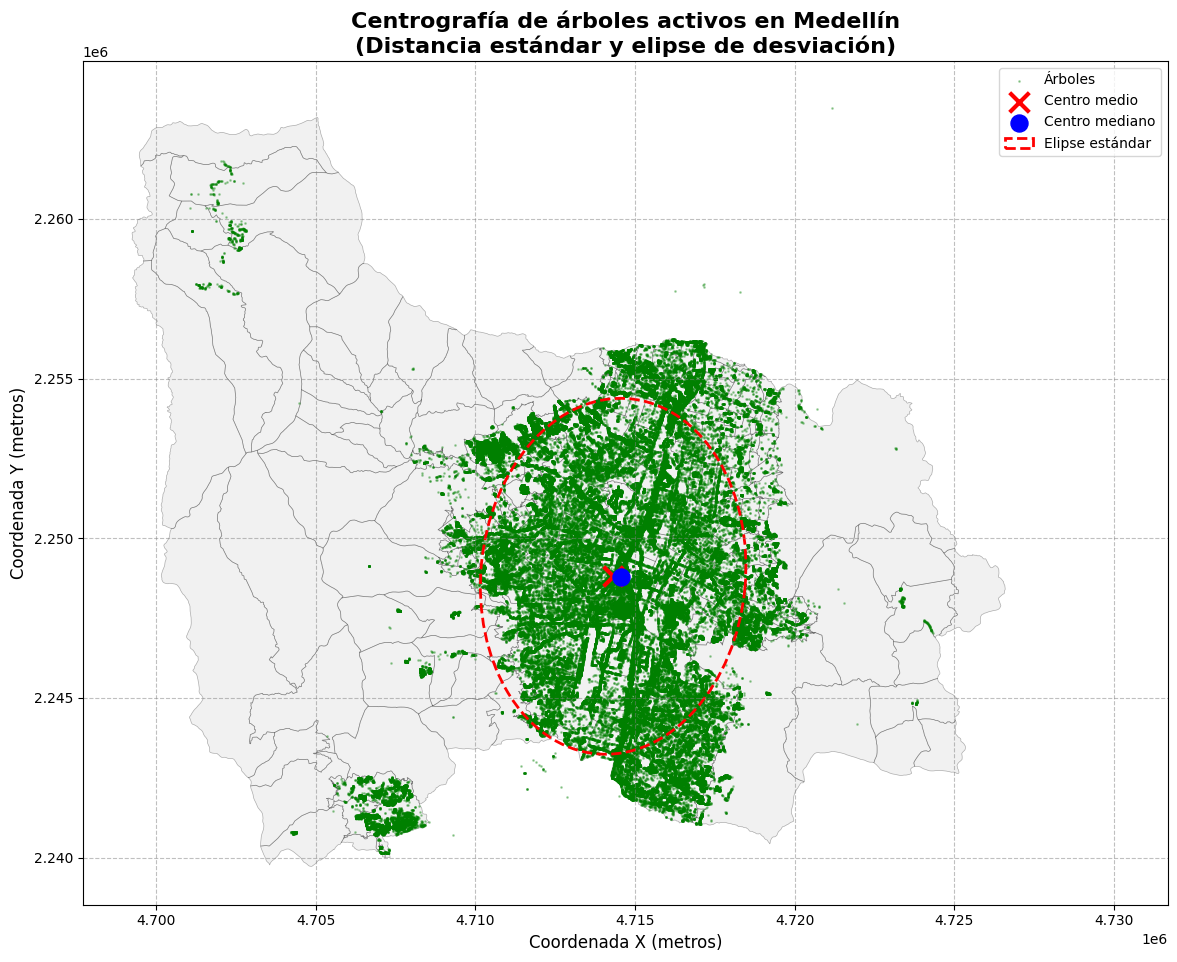

Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Centrografia_Arboles_Medellin.png


In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pointpats import centrography
import os

# Cargar zonas (barrios y veredas) para el fondo
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar los árboles
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f" Zonas cargadas: {len(zonas)}")
print(f" Árboles cargados: {len(arboles)}")

#Coordenadas

def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f" Árboles con coordenadas: {len(arboles_clean)}")

# Crear un array de coordenadas para pointpats
coords = arboles_clean[['x', 'y']].values

#Centrografía

# Centro medio (mean center)
mean_center = centrography.mean_center(coords)
print(f"Centro medio: ({mean_center[0]:.2f}, {mean_center[1]:.2f})")

# Centro mediano (euclidean median)
med_center = centrography.euclidean_median(coords)
print(f"Centro mediano: ({med_center[0]:.2f}, {med_center[1]:.2f})")

# Distancia estándar

std_dist = centrography.std_distance(coords)
print(f"Distancia estándar: {std_dist:.2f} metros")
print(f"En promedio, los árboles están a {std_dist/1000:.2f} km del centro medio")

major, minor, rotation = centrography.ellipse(coords)
print(f"Elipse estándar:")
print(f"Eje mayor: {major:.2f} metros")
print(f"Eje menor: {minor:.2f} metros")
print(f"Rotación: {np.rad2deg(rotation):.2f}°")

# Crear figura y eje
fig, ax = plt.subplots(1, figsize=(14, 12))

#
zonas.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.5, alpha=0.3)

# 
ax.scatter(
    arboles_clean['x'], 
    arboles_clean['y'],
    s=1,                # Tamaño del punto
    c='green',          # Color verde
    alpha=0.3,          # Transparencia
    label='Árboles'
)

#
ax.scatter(
    mean_center[0], mean_center[1], 
    color='red', marker='x', s=200, linewidths=3,
    label='Centro medio'
)

# --- PASO 4: Centro mediano ---
ax.scatter(
    med_center[0], med_center[1], 
    color='blue', marker='o', s=150, 
    label='Centro mediano'
)

# 
ellipse = Ellipse(
    xy=mean_center,
    width=major * 2,
    height=minor * 2,
    angle=np.rad2deg(rotation),
    facecolor='none',
    edgecolor='red',
    linestyle='--',
    linewidth=2,
    label='Elipse estándar'
)
ax.add_patch(ellipse)

# 
ax.set_title('Centrografía de árboles activos en Medellín\n(Distancia estándar y elipse de desviación)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Coordenada X (metros)', fontsize=12)
ax.set_ylabel('Coordenada Y (metros)', fontsize=12)

# Añadir grilla
ax.grid(True, linestyle='--', alpha=0.5, color='gray')

# Leyenda
ax.legend(loc='upper right')

# Guardar el gráfico
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

ruta_grafico = os.path.join(ruta_resultados, "Centrografia_Arboles_Medellin.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado en: {ruta_grafico}")

Árboles cargados: 234824
Árboles con coordenadas: 234824
Usando muestra de 5000 puntos para agilizar el cálculo
Forma de g_test.support: (50,)
Forma de g_test.simulations: (9999, 50)


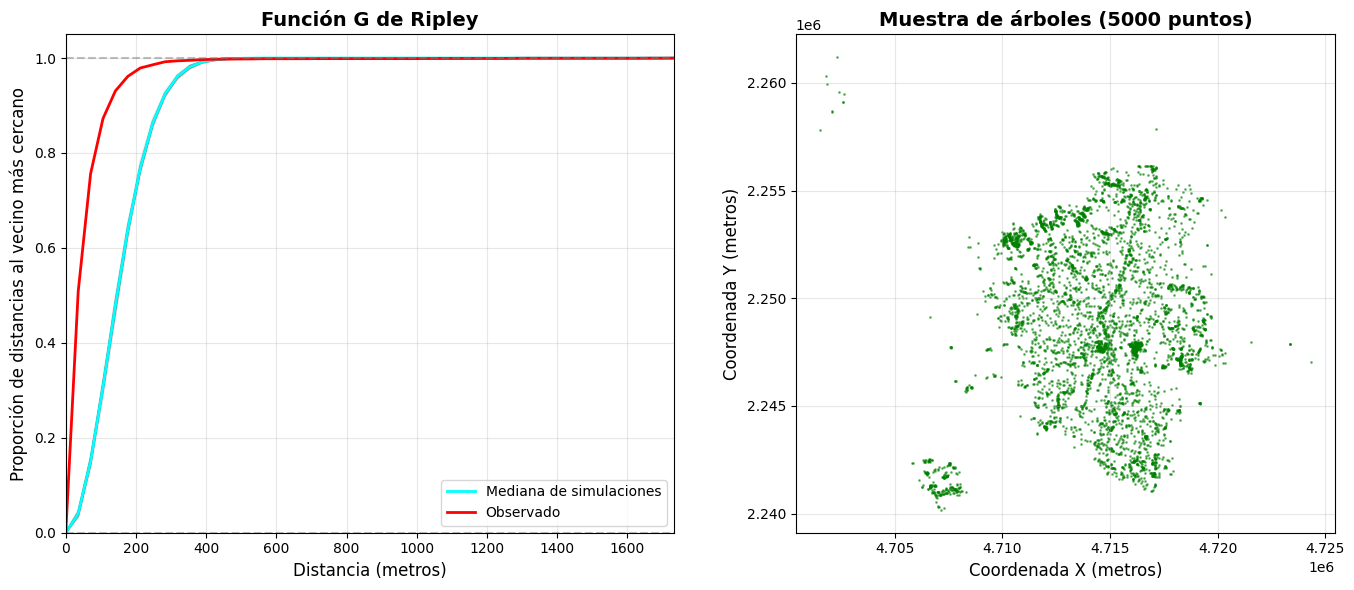

✅ Gráfico G guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Ripley_G_Arboles_Final.png


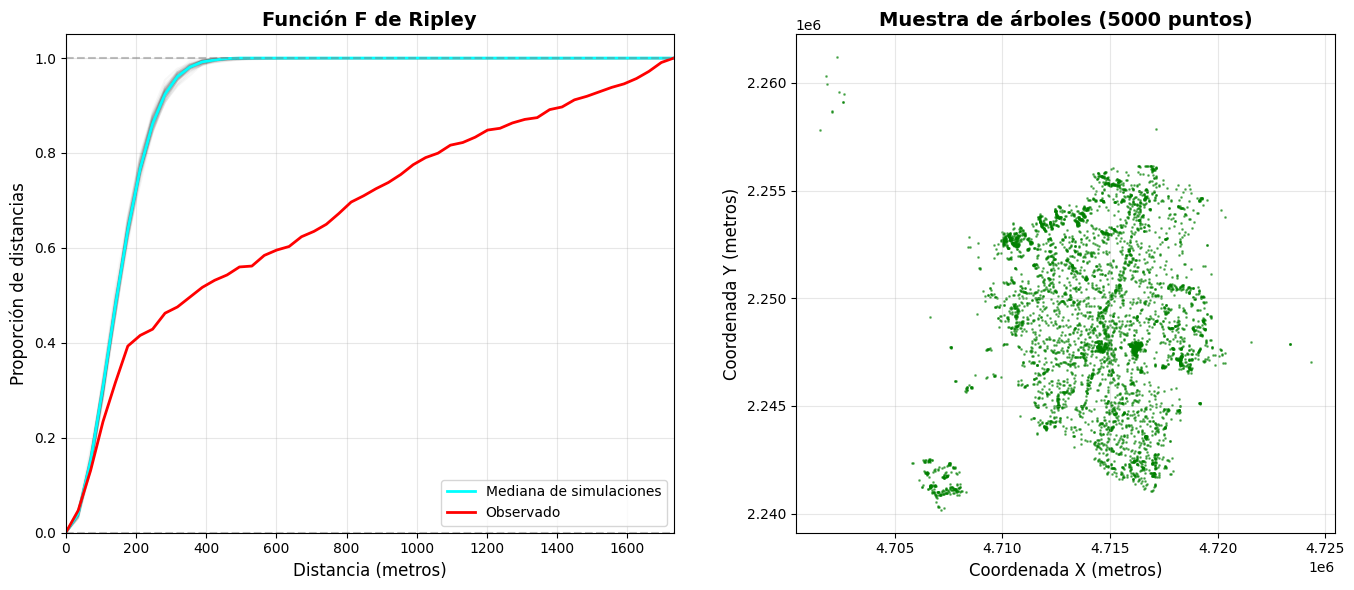

Gráfico F guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\Ripley_F_Arboles_Final.png


In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pointpats import distance_statistics
import os
import warnings
warnings.filterwarnings('ignore')

# Cargar los árboles
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f"Árboles cargados: {len(arboles)}")

# Coordenadas

def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f"Árboles con coordenadas: {len(arboles_clean)}")

# Crear un array de coordenadas para pointpats
coords = arboles_clean[['x', 'y']].values

# Si tienes muchos puntos (>5000), tomar una muestra 
if len(coords) > 5000:
    np.random.seed(42)
    idx = np.random.choice(len(coords), 5000, replace=False)
    coords_sample = coords[idx]
    print(f"Usando muestra de 5000 puntos para agilizar el cálculo")
else:
    coords_sample = coords

# Función G (Vecino más cercano)

# Calcular la función G
g_test = distance_statistics.g_test(
    coords_sample, 
    support=50,
    keep_simulations=True
)

# Verificar dimensiones
print(f"Forma de g_test.support: {g_test.support.shape}")
print(f"Forma de g_test.simulations: {g_test.simulations.shape}")

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Función G
# Asegurarse de que las dimensiones sean correctas
if g_test.simulations.shape[1] == len(g_test.support):
    # Caso: (n_simulaciones, n_support)
    n_sim_show = min(50, g_test.simulations.shape[0])
    for i in range(n_sim_show):
        axes[0].plot(g_test.support, g_test.simulations[i, :], color='k', alpha=0.03)
    
    # Línea de la mediana de las simulaciones
    axes[0].plot(g_test.support, np.median(g_test.simulations, axis=0), 
                 color='cyan', linewidth=2, label='Mediana de simulaciones')
    
else:
    # Caso: (n_support, n_simulaciones)
    n_sim_show = min(50, g_test.simulations.shape[1])
    for i in range(n_sim_show):
        axes[0].plot(g_test.support, g_test.simulations[:, i], color='k', alpha=0.03)
    
    # Línea de la mediana de las simulaciones
    axes[0].plot(g_test.support, np.median(g_test.simulations, axis=1), 
                 color='cyan', linewidth=2, label='Mediana de simulaciones')

# Línea observada
axes[0].plot(g_test.support, g_test.statistic, color='red', linewidth=2, label='Observado')

# Líneas de referencia
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# Configurar límites
max_dist = min(5000, g_test.support[-1])
axes[0].set_xlim(0, max_dist)
axes[0].set_ylim(0, 1.05)

axes[0].set_xlabel('Distancia (metros)', fontsize=12)
axes[0].set_ylabel('Proporción de distancias al vecino más cercano', fontsize=12)
axes[0].set_title("Función G de Ripley", fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Patrón de puntos (muestra)
axes[1].scatter(coords_sample[:, 0], coords_sample[:, 1], s=1, alpha=0.5, color='green')
axes[1].set_title('Muestra de árboles (5000 puntos)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coordenada X (metros)', fontsize=12)
axes[1].set_ylabel('Coordenada Y (metros)', fontsize=12)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Guardar
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

ruta_g = os.path.join(ruta_resultados, "Ripley_G_Arboles_Final.png")
plt.savefig(ruta_g, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico G guardado en: {ruta_g}")

# Función f (Distancia desde puntos aleatorios al patrón)

# Calcular la función F
f_test = distance_statistics.f_test(
    coords_sample, 
    support=50,
    keep_simulations=True
)

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Función F
if f_test.simulations.shape[1] == len(f_test.support):
    n_sim_show = min(50, f_test.simulations.shape[0])
    for i in range(n_sim_show):
        axes[0].plot(f_test.support, f_test.simulations[i, :], color='k', alpha=0.03)
    
    axes[0].plot(f_test.support, np.median(f_test.simulations, axis=0), 
                 color='cyan', linewidth=2, label='Mediana de simulaciones')
else:
    n_sim_show = min(50, f_test.simulations.shape[1])
    for i in range(n_sim_show):
        axes[0].plot(f_test.support, f_test.simulations[:, i], color='k', alpha=0.03)
    
    axes[0].plot(f_test.support, np.median(f_test.simulations, axis=1), 
                 color='cyan', linewidth=2, label='Mediana de simulaciones')

axes[0].plot(f_test.support, f_test.statistic, color='red', linewidth=2, label='Observado')

axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

max_dist = min(5000, f_test.support[-1])
axes[0].set_xlim(0, max_dist)
axes[0].set_ylim(0, 1.05)

axes[0].set_xlabel('Distancia (metros)', fontsize=12)
axes[0].set_ylabel('Proporción de distancias', fontsize=12)
axes[0].set_title("Función F de Ripley", fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Patrón de puntos
axes[1].scatter(coords_sample[:, 0], coords_sample[:, 1], s=1, alpha=0.5, color='green')
axes[1].set_title('Muestra de árboles (5000 puntos)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coordenada X (metros)', fontsize=12)
axes[1].set_ylabel('Coordenada Y (metros)', fontsize=12)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

ruta_f = os.path.join(ruta_resultados, "Ripley_F_Arboles_Final.png")
plt.savefig(ruta_f, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico F guardado en: {ruta_f}")


Zonas cargadas: 332
Árboles cargados: 234824
Árboles con coordenadas: 234824

DBSCAN - eps=300m, min_samples=10
   Clusters encontrados: 23
   Árboles en clusters: 234741 (100.0%)
   Árboles como ruido: 83 (0.0%)


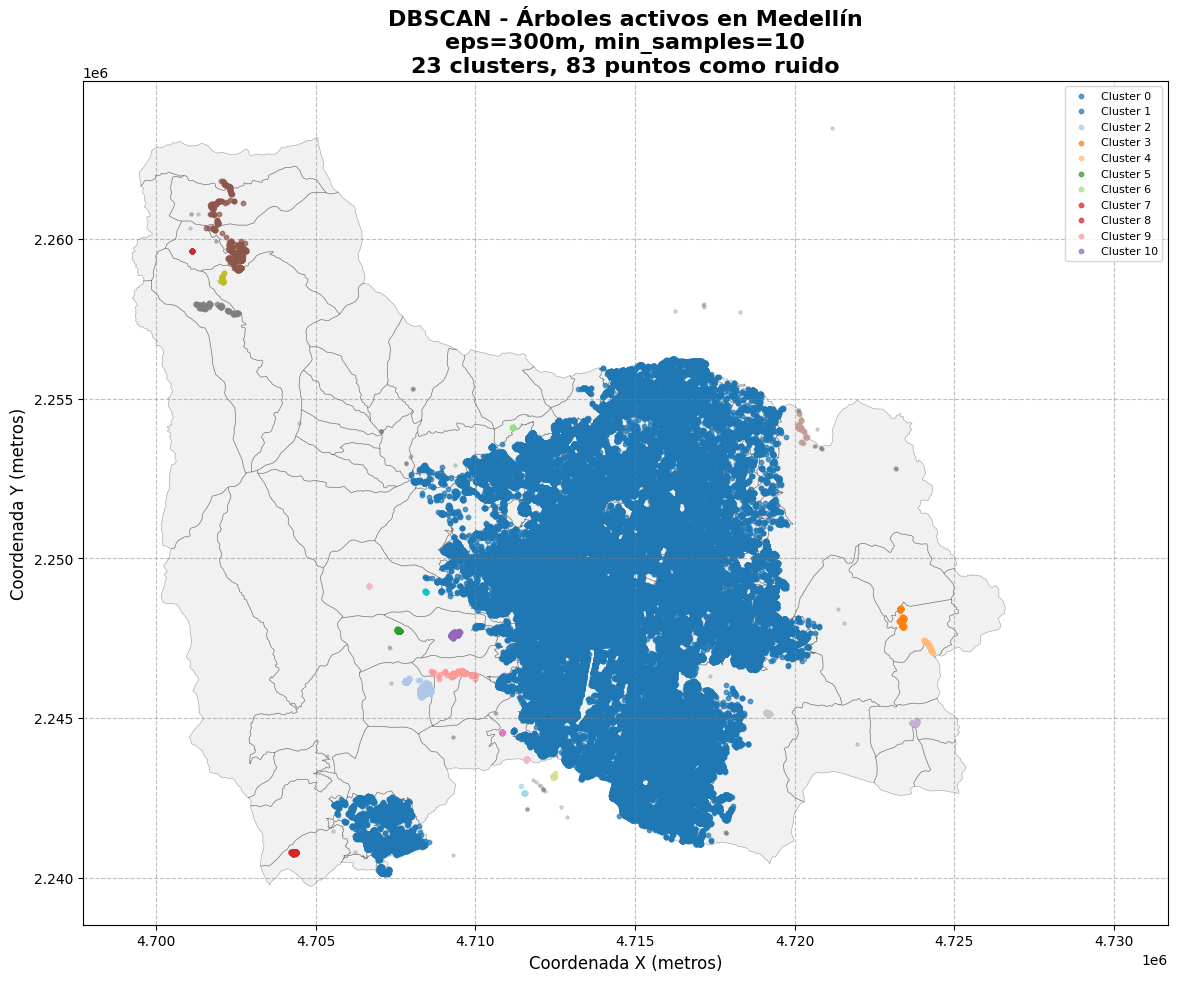

Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\DBSCAN_eps300_min10.png

DBSCAN - eps=500m, min_samples=20
   Clusters encontrados: 12
   Árboles en clusters: 234723 (100.0%)
   Árboles como ruido: 101 (0.0%)


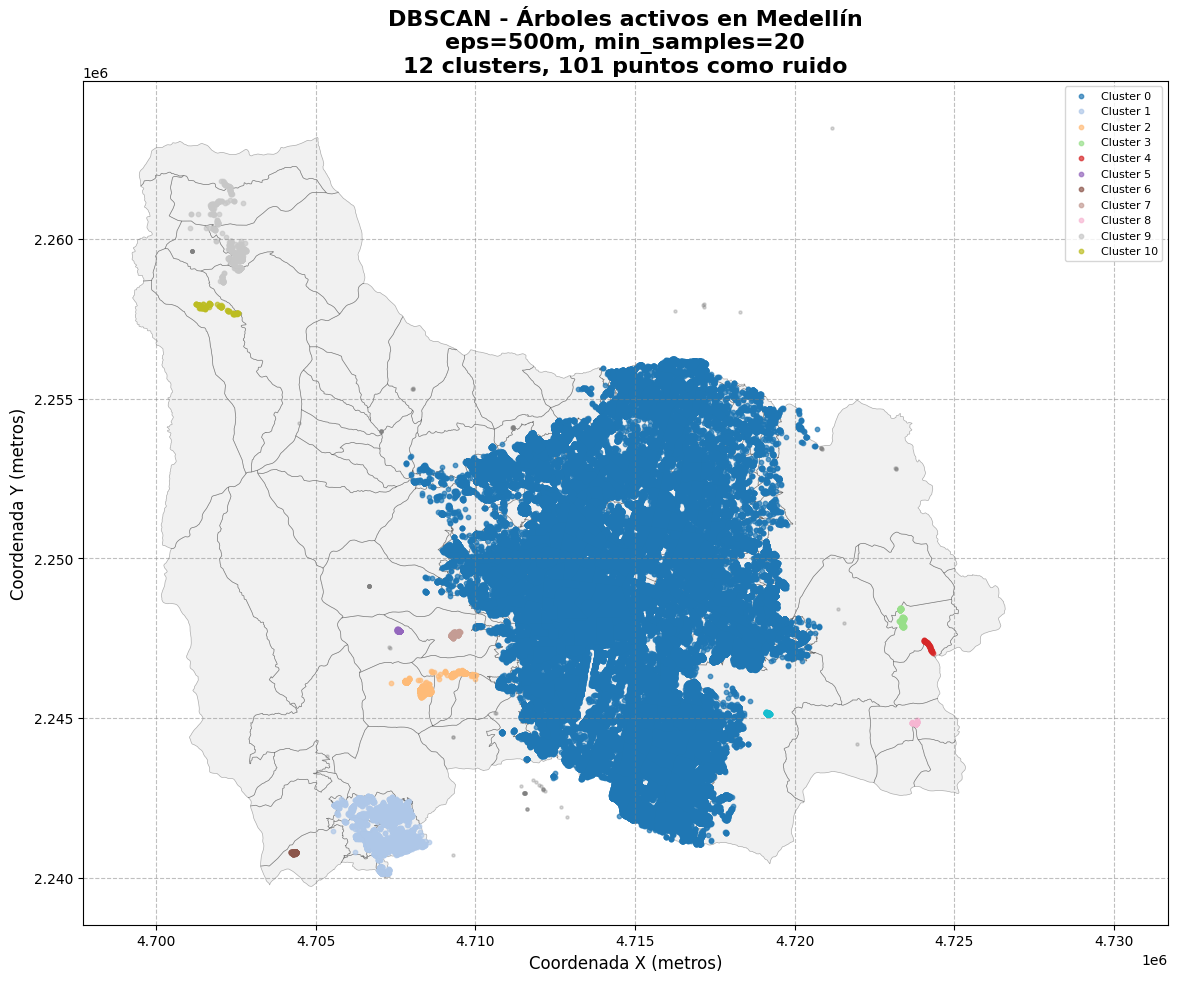

Gráfico guardado en: C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados\DBSCAN_eps500_min20.png

DBSCAN - eps=800m, min_samples=30


MemoryError: bad allocation

In [13]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import os

# Cargar zonas (barrios y veredas) para el fondo
ruta_zonas = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
zonas = gpd.read_file(ruta_zonas)

# Cargar los árboles
ruta_arboles = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Datos/Datos_procesados/Arboles_Activos_Medellin_TODOS.gpkg"
arboles = gpd.read_file(ruta_arboles)

print(f"Zonas cargadas: {len(zonas)}")
print(f"Árboles cargados (total): {len(arboles)}")

# Coordenadas
def extraer_coordenadas(geom):
    if geom.geom_type == 'Point':
        return geom.x, geom.y
    elif geom.geom_type == 'MultiPoint':
        return geom.geoms[0].x, geom.geoms[0].y
    else:
        return None, None

arboles[['x', 'y']] = arboles.geometry.apply(
    lambda geom: pd.Series(extraer_coordenadas(geom))
)
arboles_clean = arboles.dropna(subset=['x', 'y'])

print(f"Árboles con coordenadas: {len(arboles_clean)}")

muestra_size = 10000
if len(arboles_clean) > muestra_size:
    np.random.seed(42)  # Para reproducibilidad
    arboles_sample = arboles_clean.sample(n=muestra_size, random_state=42)
    print(f"Usando muestra de {muestra_size} árboles")
else:
    arboles_sample = arboles_clean
    print(f"Usando todos los árboles ({len(arboles_sample)})")

# parametros
parametros = [
    {'eps': 500, 'min_samples': 20},   # Balanceado
    {'eps': 800, 'min_samples': 30},   # Visión general
]

# Crear carpeta de resultados
ruta_resultados = r"C:/Users/manuz/OneDrive/Maestria/Análisis geoespacial/Proyecto_Curso/Resultados"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

# Para cada combinación, ejecutar DBSCAN y graficar
for i, params in enumerate(parametros):
    eps = params['eps']
    min_samples = params['min_samples']
    
    print(f"\n" + "=" * 60)
    print(f"DBSCAN - eps={eps}m, min_samples={min_samples} (muestra de {len(arboles_sample)} árboles)")
    print("=" * 60)
    
    # Aplicar DBSCAN
    clusterer = DBSCAN(eps=eps, min_samples=min_samples)
    labels = clusterer.fit_predict(arboles_sample[['x', 'y']])
    
    # Estadísticas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    pct_noise = n_noise / len(labels) * 100
    n_clustered = len(labels) - n_noise
    
    print(f"   Clusters encontrados: {n_clusters}")
    print(f"   Árboles en clusters: {n_clustered} ({100-pct_noise:.1f}%)")
    print(f"   Árboles como ruido: {n_noise} ({pct_noise:.1f}%)")
    
    # mapa
    
    fig, ax = plt.subplots(1, figsize=(14, 12))
    
    # --- Fondo: Shapes de Medellín ---
    zonas.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.5, alpha=0.3)
    
    # --- Colores para los clusters ---
    unique_labels = set(labels)
    # Usar una paleta de colores (si hay muchos clusters, se repiten)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    # Graficar cada cluster con un color diferente
    for label, color in zip(unique_labels, colors):
        if label == -1:
            # Ruido en gris
            mask = labels == -1
            ax.scatter(
                arboles_sample.loc[mask, 'x'], 
                arboles_sample.loc[mask, 'y'],
                c='gray', s=5, alpha=0.3, label='Ruido'
            )
        else:
            mask = labels == label
            ax.scatter(
                arboles_sample.loc[mask, 'x'], 
                arboles_sample.loc[mask, 'y'],
                c=[color], s=15, alpha=0.7, label=f'Cluster {label}'
            )
    
    # --- Configurar el gráfico ---
    ax.set_title(f'DBSCAN - Árboles activos en Medellín (muestra {len(arboles_sample)} árboles)\neps={eps}m, min_samples={min_samples}\n{len(unique_labels)-1} clusters, {n_noise} puntos como ruido', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Coordenada X (metros)', fontsize=12)
    ax.set_ylabel('Coordenada Y (metros)', fontsize=12)
    
    # Añadir grilla
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    
    # Leyenda (solo mostrar los primeros 10 clusters para no saturar)
    handles, labels_leg = ax.get_legend_handles_labels()
    if len(handles) > 12:
        # Mostrar solo los primeros 10 clusters + ruido
        ax.legend(handles[:11], labels_leg[:11], loc='upper right', fontsize=8)
    else:
        ax.legend(loc='upper right', fontsize=8)
    
    # --- Guardar el gráfico ---
    ruta_grafico = os.path.join(ruta_resultados, f"DBSCAN_eps{eps}_min{min_samples}_muestra.png")
    plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Gráfico guardado en: {ruta_grafico}")

print("Comparación de parámetros (muestra de 10,000 árboles):")
print("eps    min_samples   Clusters   % en clusters   % ruido")
print("---    -----------   --------   -------------   -------")

# Volver a ejecutar para mostrar el resumen
for params in parametros:
    eps = params['eps']
    min_samples = params['min_samples']
    clusterer = DBSCAN(eps=eps, min_samples=min_samples)
    labels = clusterer.fit_predict(arboles_sample[['x', 'y']])
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    pct_noise = n_noise / len(labels) * 100
    pct_clustered = 100 - pct_noise
    
    print(f"   {eps:>4}   {min_samples:>10}   {n_clusters:>7}   {pct_clustered:>12.1f}%   {pct_noise:>8.1f}%")